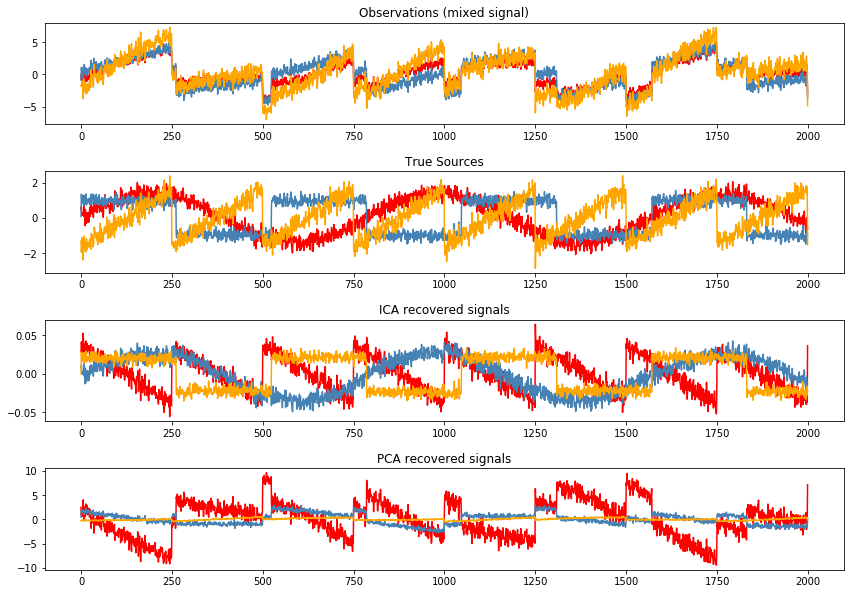

In [15]:
#sklearn中的fastICA与PCA的对比

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import FastICA, PCA


# 生成观测模拟数据
np.random.seed(0)
n_samples = 2000
time = np.linspace(0, 8, n_samples)
s1 = np.sin(2 * time)  # 信号源 1 : 正弦信号
s2 = np.sign(np.sin(3 * time))  # 信号源 2 : 方形信号
s3 = signal.sawtooth(2 * np.pi * time)  # 信号源 3: 锯齿波信号
S = np.c_[s1, s2, s3]
S += 0.2 * np.random.normal(size=S.shape)  # 增加噪音数据
S /= S.std(axis=0)  # 标准化
# 混合数据
A = np.array([[1, 1, 1], [0.5, 2, 1.0], [1.5, 1.0, 2.0]])  # 混合矩阵
X = np.dot(S, A.T)  # 生成观测信号源
# ICA模型
ica = FastICA(n_components=3)
S_ = ica.fit_transform(X)  # 重构信号
A_ = ica.mixing_  # 获得估计混合后的矩阵
# PCA模型
pca = PCA(n_components=3)
H = pca.fit_transform(X)  # 基于PCA的成分正交重构信号源
# 图形展示
plt.figure()
models = [X, S, S_, H]
names = ['Observations (mixed signal)',
         'True Sources',
         'ICA recovered signals',
         'PCA recovered signals']
colors = ['red', 'steelblue', 'orange']
for ii, (model, name) in enumerate(zip(models, names), 1):
    plt.subplot(4, 1, ii)
    plt.title(name)
    for sig, color in zip(model.T, colors):
        plt.plot(sig, color=color)
plt.subplots_adjust(0.09, 0.04, 1.94, 1.94, 0.26, 0.46)
plt.show()

#可以看出，ICA分离之后的信号顺序是不能保证的。PCA只复原了一个初始信号，ICA效果更好